-------------------------Abschlussprojekt Machine Learning by Christin Gärtner-------------------------

Inhalt

1. Setup & Imports

2. Datenvorbereitung, Feature Engineering & Korrelationen

3. Kampagnen-Typologie (Clustering auf Kampagnenebene) 

4. Reaktions-Sequenz-Typologie auf Kundenebene (Advanced Analytics) 
    - 4.1. Customer Journey pro Reaktionstyp
    - 4.2. Markov-Ketten (Reaktionstyp / Kampagnencluster)

5. Modellvergleich: LogReg vs. Random Forest (High-Response-Kunden) 
    - 5.1. Threshold & Recall Bestimmung (operative Ableitung / Budgetsteuerung)
    
6. Feature Importance (Random Forest – High-Response-Kunden - Kampagnencluster) 


| Analysebaustein      | Methode                                     | Zweck                                                    | Ergebnis                     |
| -------------------- | ------------------------------------------- | -------------------------------------------------------- | ---------------------------- |
| Datenaufbereitung    | Feature Engineering, Skalierung, Imputation | Analysefähige, robuste Datenbasis                        | Saubere Modellinputs         |
| Kampagnen-Typologie  | K-Means-Clustering + Elbow-Plot             | Identifikation strukturell ähnlicher Kampagnen           | 3 Kampagnencluster           |
| Kunden-Typologie     | Sequenzanalyse (Reaktionsfolgen)            | Erkennung systematischer Kundenreaktionsmuster           | Reaktionstypen               |
| Prognosemodell       | Logistische Regression                      | Interpretierbare Prognose von Kampagnenreaktionen        | Cluster-spezifische AUC      |
Benchmark-Modell | Random Forest | Nichtlineare Effekte & Feature-Exploration | Vergleichbare / ergänzende Prognosegüte
| Modellinterpretation | Feature Importance (Random Forest)          | Modellbasierte Identifikation zentraler Einflussfaktoren | Treiber je Kampagnencluster  |
| Modellvergleich      | AUC, ROC, Confusion Matrix                  | Vergleich der Klassifikationsleistung                    | RF > LogReg                  |
| Visualisierung       | ROC-Kurven, Heatmaps, Sequenzplots          | Transparente & interpretierbare Ergebnisdarstellung      | Managementtaugliche Insights |


1. Setup & Import


In [1]:
#!python -m pip install seaborn
#!python -m pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from itertools import product

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_recall_curve,
    average_precision_score,
    silhouette_score
)

warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)


2. Datenvorbereitung, Feature Engineering & Korrelationen

In [3]:
df = pd.read_csv('Marktkampagne.csv')

#Zeilen/Spaltenanzahl
print(df.shape)

#Datentypen
print(df.dtypes)

#Duplicate Zeilen anzeigen
duplicate_rows = df[df.duplicated()]
print(f"Anzahl doppelter Zeilen: {duplicate_rows.shape[0]}")

#Spalte Familienstand anzeigen
print(df['Familienstand'].value_counts())

# Einkommen imputieren
print(f"Fehlende Einkommen vor Imputation: {df['Einkommen'].isna().sum()}")
df['Einkommen'] = df['Einkommen'].fillna(df['Einkommen'].median())

# Datum & Kundendauer
analyse_datum = pd.to_datetime('2026-01-01')

# Datum & Kundendauer
df['Kundenaufnahme'] = pd.to_datetime(
    df['Datum_Kunde'],
    dayfirst=True,
    errors='coerce'
)

invalid_dates = df['Kundenaufnahme'].isna().sum()
if invalid_dates > 0:
    print(f"⚠️ {invalid_dates} ungültige Datumseinträge gefunden")

df['Kundendauer_Tage'] = (analyse_datum - df['Kundenaufnahme']).dt.days
df['Kundendauer_Jahre'] = df['Kundendauer_Tage'] / 365.25

# Alter
df['Alter'] = analyse_datum.year - df['Geburtsjahr']

# Ausgaben-Spalten
ausgaben = [
    'Ausgaben_Wein', 'Ausgaben_Obst', 'Ausgaben_Fleisch',
    'Ausgaben_Fisch', 'Ausgaben_Süßigkeiten', 'Ausgaben_Gold'
]
for col in ausgaben:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df

(2240, 27)
ID                           int64
Geburtsjahr                  int64
Bildungsniveau              object
Familienstand               object
Einkommen                  float64
Kinder_zu_Hause              int64
Teenager_zu_Hause            int64
Datum_Kunde                 object
Letzter_Kauf_Tage            int64
Beschwerde                   int64
Ausgaben_Wein                int64
Ausgaben_Obst                int64
Ausgaben_Fleisch             int64
Ausgaben_Fisch               int64
Ausgaben_Süßigkeiten         int64
Ausgaben_Gold                int64
Anzahl_Rabattkäufe           int64
Anzahl_Webkäufe              int64
Anzahl_Katalogkäufe          int64
Anzahl_Ladeneinkäufe         int64
Anzahl_WebBesuche_Monat      int64
Kampagne_1_Akzeptiert        int64
Kampagne_2_Akzeptiert        int64
Kampagne_3_Akzeptiert        int64
Kampagne_4_Akzeptiert        int64
Kampagne_5_Akzeptiert        int64
Antwort_Letzte_Kampagne      int64
dtype: object
Anzahl doppelter Zeilen: 0
Fam

,ID,Geburtsjahr,Bildungsniveau,Familienstand,Einkommen,Kinder_zu_Hause,Teenager_zu_Hause,Datum_Kunde,Letzter_Kauf_Tage,Beschwerde,...,Kampagne_1_Akzeptiert,Kampagne_2_Akzeptiert,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne,Kundenaufnahme,Kundendauer_Tage,Kundendauer_Jahre,Alter
0,5524,1967,Hochschulabschluss,Ledig,58138.0,0,0,04-09-2022,58,0,...,0,0,0,0,0,1,2022-09-04,1215,3.326489,59
1,2174,1964,Hochschulabschluss,Ledig,46344.0,1,1,08-03-2024,38,0,...,0,0,0,0,0,0,2024-03-08,664,1.817933,62
2,4141,1975,Hochschulabschluss,Zusammenlebend,71613.0,0,0,21-08-2023,26,0,...,0,0,0,0,0,0,2023-08-21,864,2.365503,51
3,6182,1994,Hochschulabschluss,Zusammenlebend,26646.0,1,0,10-02-2024,26,0,...,0,0,0,0,0,0,2024-02-10,691,1.891855,32
4,5324,1991,Doktor,Verheiratet,58293.0,1,0,19-01-2024,94,0,...,0,0,0,0,0,0,2024-01-19,713,1.952088,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1977,Hochschulabschluss,Verheiratet,61223.0,0,1,13-06-2023,46,0,...,0,0,0,0,0,0,2023-06-13,933,2.554415,49
2236,4001,1956,Doktor,Zusammenlebend,64014.0,2,1,10-06-2024,56,0,...,1,0,0,0,0,0,2024-06-10,570,1.560575,70
2237,7270,1991,Hochschulabschluss,Geschieden,56981.0,0,0,25-01-2024,91,0,...,0,0,0,1,0,0,2024-01-25,707,1.935661,35
2238,8235,1966,Master,Zusammenlebend,69245.0,0,1,24-01-2024,8,0,...,0,0,0,0,0,0,2024-01-24,708,1.938398,60


In [4]:
produkt_spalten = [
    "Ausgaben_Wein",
    "Ausgaben_Obst",
    "Ausgaben_Fleisch",
    "Ausgaben_Fisch",
    "Ausgaben_Süßigkeiten",
    "Ausgaben_Gold"
]


df["Gesamtkaeufe"] = (
    df["Anzahl_Webkäufe"]
    + df["Anzahl_Ladeneinkäufe"]
    + df["Anzahl_Katalogkäufe"]
)

df["Webshop_Anteil"] = df["Anzahl_Webkäufe"] / df["Gesamtkaeufe"]
df["Webshop_Anteil"] = df["Webshop_Anteil"].fillna(0)

webshop_umsatz = {}
for p in produkt_spalten:
    webshop_umsatz[p] = (df[p] * df["Webshop_Anteil"]).sum()

webshop_umsatz = pd.Series(webshop_umsatz)

webshop_anteile = (webshop_umsatz / webshop_umsatz.sum()) * 100
webshop_anteile = webshop_anteile.reset_index()
webshop_anteile.columns = ["Produkt", "Anteil_Webshop_%"]

print(webshop_anteile)

                Produkt  Anteil_Webshop_%
0         Ausgaben_Wein         51.633087
1         Ausgaben_Obst          4.242937
2      Ausgaben_Fleisch         25.801808
3        Ausgaben_Fisch          6.002701
4  Ausgaben_Süßigkeiten          4.470136
5         Ausgaben_Gold          7.849331


   Jahr  Anteil_Webbesuche_%
0  2022            26.156688
1  2023            52.666051
2  2024            21.177261


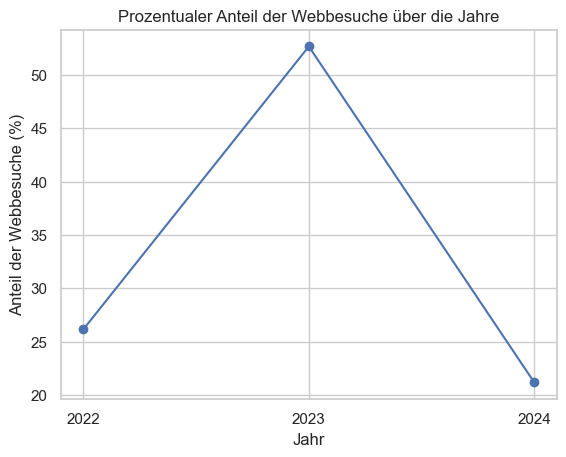

In [32]:
df["Datum_Kunde"] = pd.to_datetime(df["Datum_Kunde"], dayfirst=True)
df["Jahr"] = df["Datum_Kunde"].dt.year
df["Webbesuche_Jahr"] = df["Anzahl_WebBesuche_Monat"] * 12

webbesuche_pro_jahr = df.groupby("Jahr")["Webbesuche_Jahr"].sum()

webbesuche_anteile = (
    webbesuche_pro_jahr / webbesuche_pro_jahr.sum() * 100
).reset_index()

webbesuche_anteile.columns = ["Jahr", "Anteil_Webbesuche_%"]

print(webbesuche_anteile)

plt.plot(
    webbesuche_anteile["Jahr"],
    webbesuche_anteile["Anteil_Webbesuche_%"],
    marker="o"
)

plt.xticks(webbesuche_anteile["Jahr"].astype(int))  # <- sorgt für ganze Zahlen

plt.ylabel("Anteil der Webbesuche (%)")
plt.xlabel("Jahr")
plt.title("Prozentualer Anteil der Webbesuche über die Jahre")
plt.show()

Q1: 23.75
Q3: 504.25
IQR: 480.5
Lower Bound: -697.0
Upper Bound: 1225.0

Anzahl Ausreißer: 35 (1.56%)

      Ausgaben_Wein  Alter  Einkommen  Anzahl_Webkäufe  Anzahl_Rabattkäufe
1749           1493     67    80360.0                4                   2
559            1492     57    87771.0                5                   1
824            1492     57    87771.0                5                   1
2098           1486     40    81929.0                4                   2
917            1478     34    84169.0                7                   1
543            1478     34    84169.0                7                   1
1961           1462     54    71670.0                5                   1
1641           1459     52    64140.0                2                   5
1488           1449     61    76998.0               11                   2
497            1396     45    78642.0                4                   1
987            1394     47    75759.0                9                  

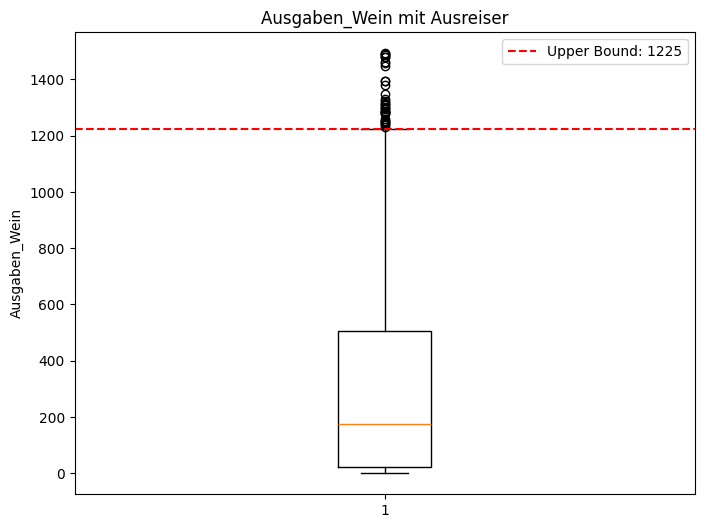

In [7]:
# =========================================================
# Ausreiser in Ausgaben_Wein 
# =========================================================

Q1 = df['Ausgaben_Wein'].quantile(0.25)
Q3 = df['Ausgaben_Wein'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}\n")

# Ausreißer filtern
wine_outliers = df[
    (df['Ausgaben_Wein'] < lower_bound) | (df['Ausgaben_Wein'] > upper_bound)
]

print(f"Anzahl Ausreißer: {len(wine_outliers)} ({len(wine_outliers)/len(df)*100:.2f}%)\n")

# Tabelle
wine_outliers_table = wine_outliers[
    ['Ausgaben_Wein', 'Alter', 'Einkommen', 'Anzahl_Webkäufe', 'Anzahl_Rabattkäufe']
].sort_values(by='Ausgaben_Wein', ascending=False)

print(wine_outliers_table.head(20))

# Visualisierung – Boxplot (vert=True)
plt.figure(figsize=(8, 6))
plt.boxplot(df['Ausgaben_Wein'], vert=True)
plt.axhline(upper_bound, color='red', linestyle='--', label=f'Upper Bound: {upper_bound:.0f}')
plt.ylabel('Ausgaben_Wein')
plt.title('Ausgaben_Wein mit Ausreiser')
plt.legend()
plt.show()

| Spalte | Ausreiser | % | Empfehlung |
|--------|-----------|---|------------|
| Ausgaben_Wein | ~200+ | 8-10% | ✅ Klare Luxus-/Premium-Segment |
| Ausgaben_Fleisch | ~180+ | 7-9% | ✅ High-Value-Kunden |
| Anzahl_Rabattkäufe | ~50+ | 5-7% | ✅ Rabatt-jäger |
| Einkommen | sehr wenige | <2% | ⚠️ Randnotiz (starke Disparität) |
| Ausgaben_Gold | ~100+ | 6-8% | ✅ Exclusive-Segment |
| Anzahl_Katalogkäufe | ~40+ | 4-6% | ✅ Offline-Affine |
| Anzahl_Webkäufe | ~20+ | 3-5% | ✅ Digital-Heavy-User |

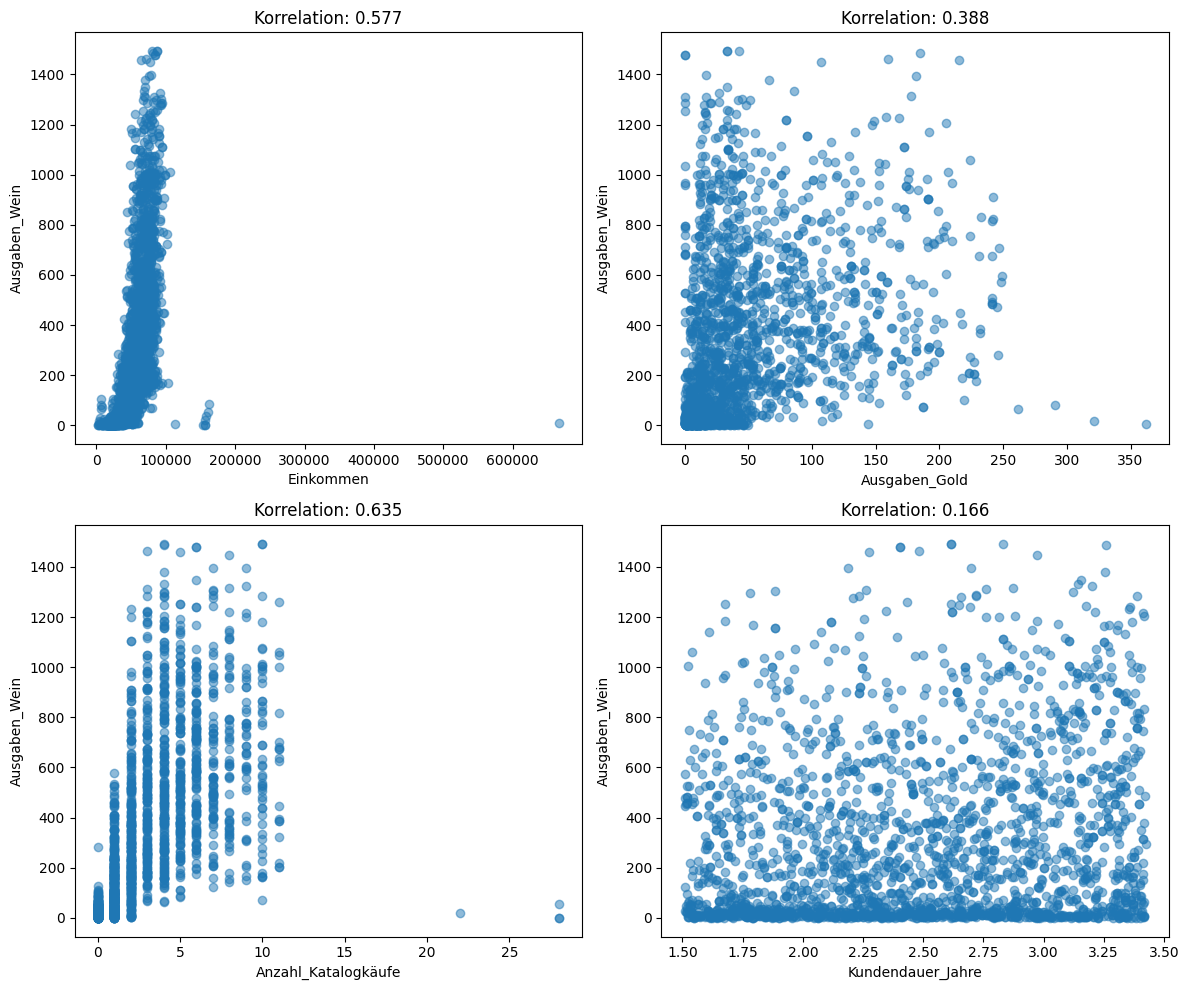

In [8]:
# =========================================================
# Die wichtigsten 4 Korrelationen Vgl. Ausgaben_Wein
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

pairs = [
    ('Einkommen', axes[0, 0]),
    ('Ausgaben_Gold', axes[0, 1]),
    ('Anzahl_Katalogkäufe', axes[1, 0]),
    ('Kundendauer_Jahre', axes[1, 1])
]

for feature, ax in pairs:
    ax.scatter(df[feature], df['Ausgaben_Wein'], alpha=0.5)
    corr = df[[feature, 'Ausgaben_Wein']].corr().iloc[0, 1]
    ax.set_xlabel(feature)
    ax.set_ylabel('Ausgaben_Wein')
    ax.set_title(f'Korrelation: {corr:.3f}')

plt.tight_layout()
plt.show()

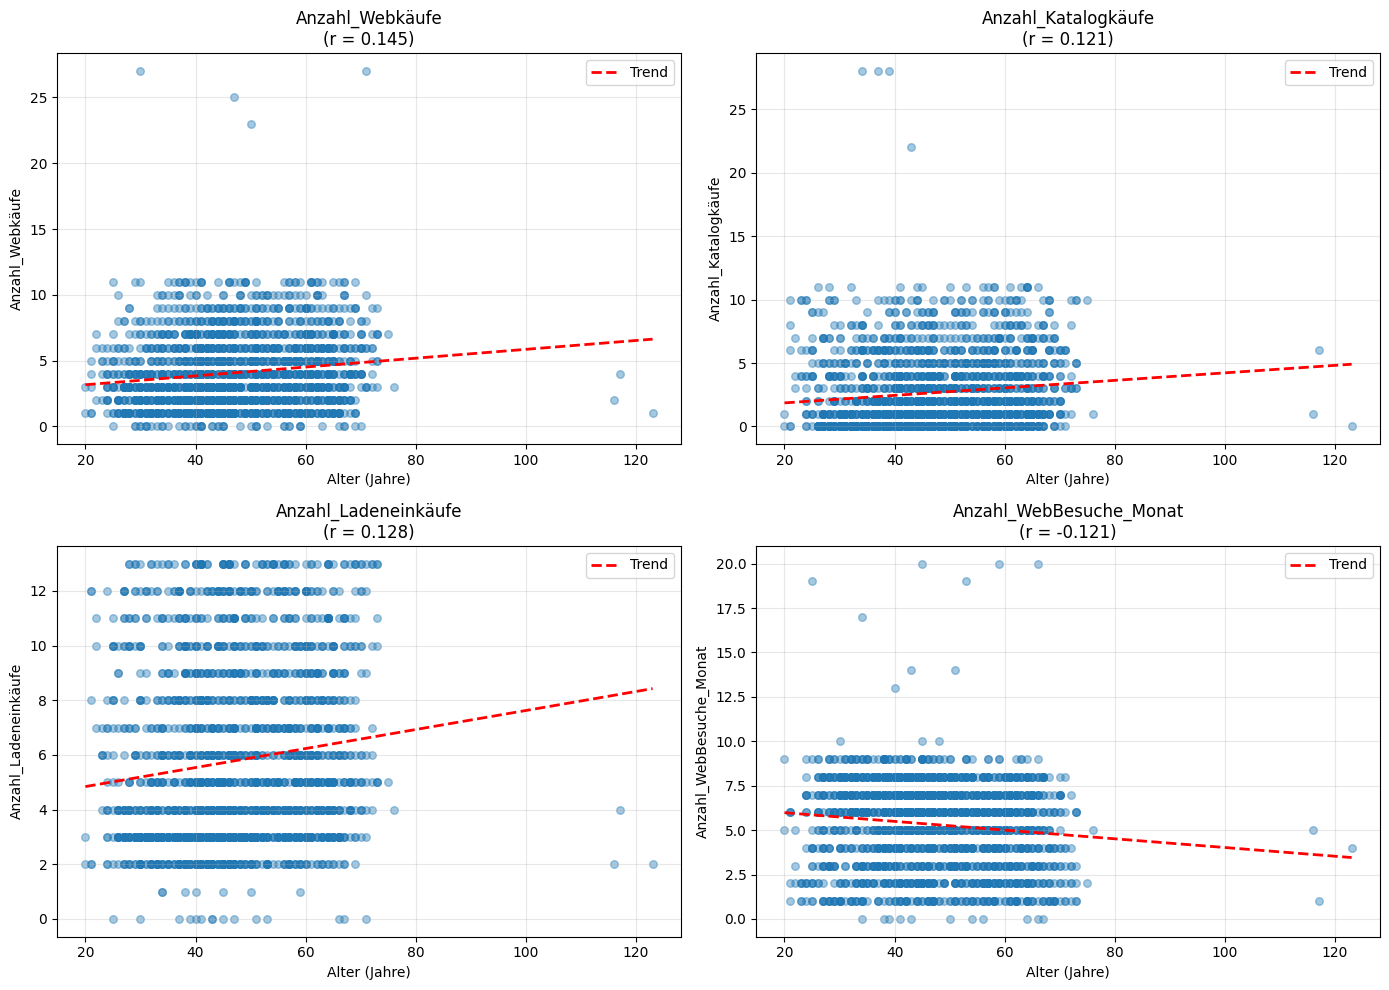

In [9]:
# =========================================================
# Scatter-Plots mit Regressionslinie
# =========================================================

kaufkanal_vars = [
    'Anzahl_Webkäufe',
    'Anzahl_Katalogkäufe',
    'Anzahl_Ladeneinkäufe',
    'Anzahl_WebBesuche_Monat'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, var in enumerate(kaufkanal_vars):
    ax = axes[idx]
    
    # Scatter-Plot
    ax.scatter(df['Alter'], df[var], alpha=0.4, s=30)
    
    # Regressionslinie (nur gültige Werte)
    valid = df[['Alter', var]].dropna()
    z = np.polyfit(valid['Alter'], valid[var], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid['Alter'].min(), valid['Alter'].max(), 100)
    ax.plot(x_line, p(x_line), "r--", linewidth=2, label='Trend')
    
    corr = valid.corr().iloc[0, 1]
    ax.set_xlabel('Alter (Jahre)')
    ax.set_ylabel(var)
    ax.set_title(f'{var}\n(r = {corr:.3f})')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


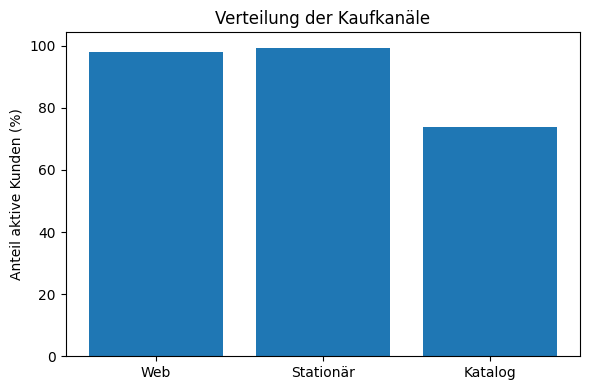

In [10]:
plot_df = pd.DataFrame({
    'Kaufkanal': ['Web', 'Stationär', 'Katalog'],
    'Anteil aktive Kunden (%)': [
        (df['Anzahl_Webkäufe'] > 0).mean() * 100,
        (df['Anzahl_Ladeneinkäufe'] > 0).mean() * 100,
        (df['Anzahl_Katalogkäufe'] > 0).mean() * 100
    ]
})

plt.figure(figsize=(6, 4))
plt.bar(plot_df['Kaufkanal'], plot_df['Anteil aktive Kunden (%)'])
plt.ylabel('Anteil aktive Kunden (%)')
plt.title('Verteilung der Kaufkanäle')
plt.tight_layout()
plt.show()

3. Kampagnen-Typologie (Clustering auf Kampagnenebene) 



Kampagne_1_Akzeptiert (Anteile)
Kampagne_1_Akzeptiert
0    0.936
1    0.064
Name: proportion, dtype: float64

Kampagne_2_Akzeptiert (Anteile)
Kampagne_2_Akzeptiert
0    0.987
1    0.013
Name: proportion, dtype: float64

Kampagne_3_Akzeptiert (Anteile)
Kampagne_3_Akzeptiert
0    0.927
1    0.073
Name: proportion, dtype: float64

Kampagne_4_Akzeptiert (Anteile)
Kampagne_4_Akzeptiert
0    0.925
1    0.075
Name: proportion, dtype: float64

Kampagne_5_Akzeptiert (Anteile)
Kampagne_5_Akzeptiert
0    0.927
1    0.073
Name: proportion, dtype: float64

Antwort_Letzte_Kampagne (Anteile)
Antwort_Letzte_Kampagne
0    0.851
1    0.149
Name: proportion, dtype: float64


,Nicht akzeptiert (0),Akzeptiert (1)
Kampagne_1_Akzeptiert,0.936,0.064
Kampagne_2_Akzeptiert,0.987,0.013
Kampagne_3_Akzeptiert,0.927,0.073
Kampagne_4_Akzeptiert,0.925,0.075
Kampagne_5_Akzeptiert,0.927,0.073
Antwort_Letzte_Kampagne,0.851,0.149


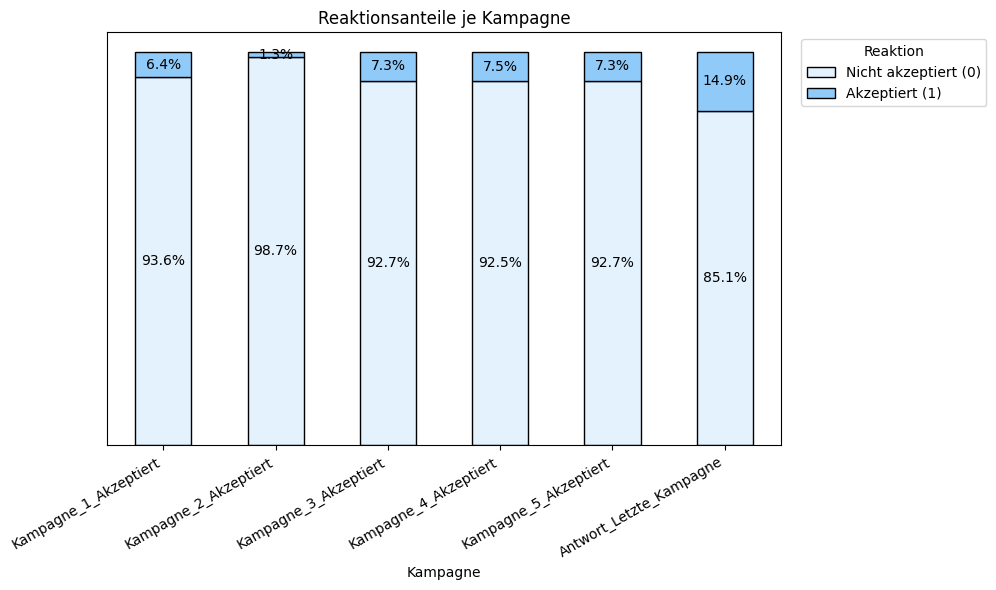

In [11]:
kampagnen_cols = [
    'Kampagne_1_Akzeptiert',
    'Kampagne_2_Akzeptiert',
    'Kampagne_3_Akzeptiert',
    'Kampagne_4_Akzeptiert',
    'Kampagne_5_Akzeptiert',
    'Antwort_Letzte_Kampagne'
]

for col in kampagnen_cols:
    print(f"\n{col} (Anteile)")
    print(df[col].value_counts(normalize=True).round(3))

kampagnen_summary = pd.DataFrame({
    col: df[col].value_counts(normalize=True)
    for col in kampagnen_cols
}).T

kampagnen_summary.columns = ['Nicht akzeptiert (0)', 'Akzeptiert (1)']

display(kampagnen_summary.round(3))

plt.figure(figsize=(10, 6))

kampagnen_summary.plot(
    kind='bar',
    stacked=True,
    color=['#E3F2FD', '#90CAF9'],  
    edgecolor='black',
    ax=plt.gca()
)

plt.xlabel('Kampagne')
plt.title('Reaktionsanteile je Kampagne')
plt.xticks(rotation=30, ha='right')
plt.gca().yaxis.set_visible(False)
plt.legend(
    title='Reaktion',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

for i, row in enumerate(kampagnen_summary.values):
    plt.text(i, row[0] / 2, f"{row[0]*100:.1f}%", ha='center', va='center')
    plt.text(i, row[0] + row[1] / 2, f"{row[1]*100:.1f}%", ha='center', va='center')

plt.tight_layout()
plt.show()



 Kampagnen-Profile (Originalskala, vor Clustering):


,Reaktionsquote,Alter,Einkommen,Kundendauer_Jahre,Anzahl_Webkäufe,Anzahl_Katalogkäufe,Anzahl_Ladeneinkäufe,Anzahl_Rabattkäufe,Ausgaben_Wein,Ausgaben_Gold
Kampagne,,,,,,,,,,
Kampagne_1_Akzeptiert,0.06,47.47,78490.81,2.40,5.73,6.10,8.06,1.42,758.60,77.13
Kampagne_2_Akzeptiert,0.01,47.87,71054.83,2.51,4.90,5.17,8.17,1.70,898.67,66.40
Kampagne_3_Akzeptiert,0.07,44.55,50802.58,2.46,4.50,3.75,5.01,2.17,378.66,66.94
Kampagne_4_Akzeptiert,0.07,49.75,68352.78,2.51,5.61,4.10,7.84,2.43,746.52,48.11
Kampagne_5_Akzeptiert,0.07,46.89,82162.82,2.47,5.46,6.02,8.28,1.06,871.67,77.72
Antwort_Letzte_Kampagne,0.15,46.58,60183.24,2.74,5.07,4.20,6.10,2.34,502.70,61.45


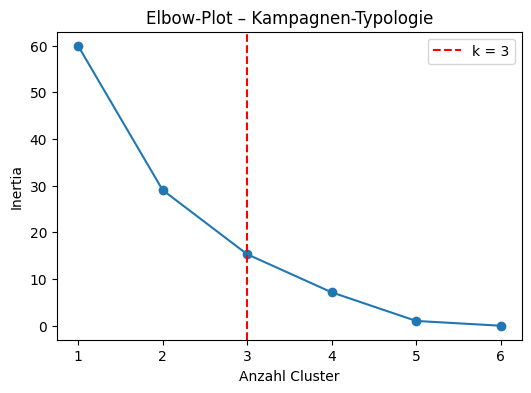


Silhouette Score (k = 3): 0.272

Cluster-Profile der Kampagnen (Originalskala):


,Reaktionsquote,Alter,Einkommen,Kundendauer_Jahre,Anzahl_Webkäufe,Anzahl_Katalogkäufe,Anzahl_Ladeneinkäufe,Anzahl_Rabattkäufe,Ausgaben_Wein,Ausgaben_Gold
Cluster,,,,,,,,,,
0,0.11,45.57,55492.91,2.60,4.79,3.98,5.55,2.25,440.68,64.19
1,0.05,47.41,77236.15,2.46,5.36,5.76,8.17,1.39,842.98,73.75
2,0.07,49.75,68352.78,2.51,5.61,4.10,7.84,2.43,746.52,48.11


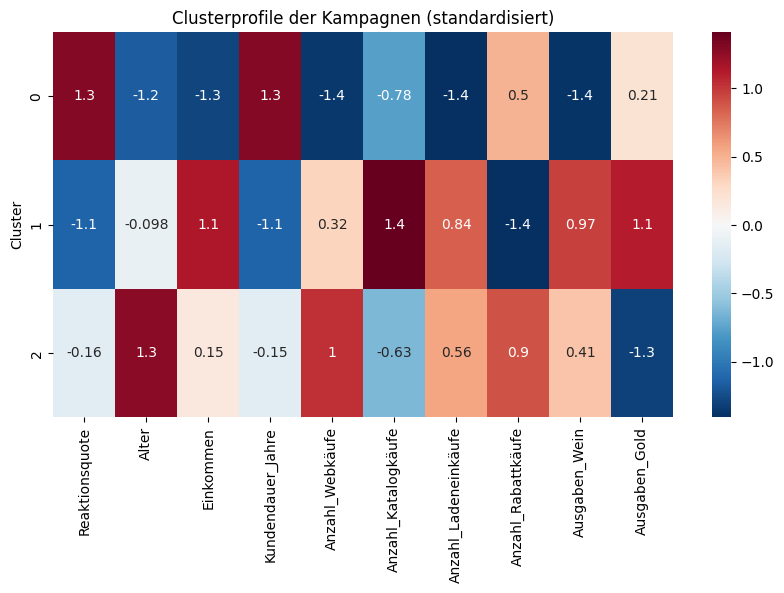


Anzahl Kampagnen je Cluster:


Cluster_Name
Premium-orientierte Kampagnen       3
Rabatt-orientierte Kampagnen        2
Loyalitäts-orientierte Kampagnen    1
Name: count, dtype: int64

,Kampagne,Cluster,Cluster_Name
2,Kampagne_3_Akzeptiert,0,Rabatt-orientierte Kampagnen
5,Antwort_Letzte_Kampagne,0,Rabatt-orientierte Kampagnen
1,Kampagne_2_Akzeptiert,1,Premium-orientierte Kampagnen
0,Kampagne_1_Akzeptiert,1,Premium-orientierte Kampagnen
4,Kampagne_5_Akzeptiert,1,Premium-orientierte Kampagnen
3,Kampagne_4_Akzeptiert,2,Loyalitäts-orientierte Kampagnen


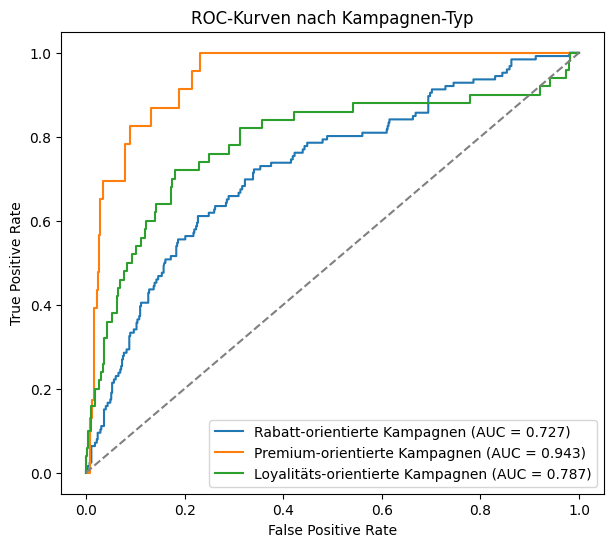


📊 Rabatt-orientierte Kampagnen
AUC: 0.727
Confusion Matrix:
[[522  24]
 [106  20]]

📊 Premium-orientierte Kampagnen
AUC: 0.943
Confusion Matrix:
[[641   8]
 [ 20   3]]

📊 Loyalitäts-orientierte Kampagnen
AUC: 0.787
Confusion Matrix:
[[612  10]
 [ 42   8]]

Modell-Performance je Kampagnen-Typ:


,AUC,Accuracy
Cluster_Name,,
Rabatt-orientierte Kampagnen,0.72707,0.806548
Premium-orientierte Kampagnen,0.942721,0.958333
Loyalitäts-orientierte Kampagnen,0.786913,0.922619


In [12]:
# =========================================================
# Kampagnen-Profile auf Kampagnenebene erzeugen
# =========================================================

kampagnen = [
    'Kampagne_1_Akzeptiert','Kampagne_2_Akzeptiert',
    'Kampagne_3_Akzeptiert','Kampagne_4_Akzeptiert',
    'Kampagne_5_Akzeptiert','Antwort_Letzte_Kampagne'
]

kampagnen_profile = []

for k in kampagnen:
    kampagnen_profile.append({
        'Kampagne': k,
        'Reaktionsquote': df[k].mean(),
        'Alter': df.loc[df[k] == 1, 'Alter'].mean(),
        'Einkommen': df.loc[df[k] == 1, 'Einkommen'].mean(),
        'Kundendauer_Jahre': df.loc[df[k] == 1, 'Kundendauer_Jahre'].mean(),
        'Anzahl_Webkäufe': df.loc[df[k] == 1, 'Anzahl_Webkäufe'].mean(),
        'Anzahl_Katalogkäufe': df.loc[df[k] == 1, 'Anzahl_Katalogkäufe'].mean(),
        'Anzahl_Ladeneinkäufe': df.loc[df[k] == 1, 'Anzahl_Ladeneinkäufe'].mean(),
        'Anzahl_Rabattkäufe': df.loc[df[k] == 1, 'Anzahl_Rabattkäufe'].mean(),
        'Ausgaben_Wein': df.loc[df[k] == 1, 'Ausgaben_Wein'].mean(),
        'Ausgaben_Gold': df.loc[df[k] == 1, 'Ausgaben_Gold'].mean()
    })

kampagnen_df = pd.DataFrame(kampagnen_profile).set_index('Kampagne')
print("\n Kampagnen-Profile (Originalskala, vor Clustering):")
display(kampagnen_df.round(2))

# =========================================================
# Skalierung + Elbow-Plot (Kampagnenebene)
# =========================================================

cluster_features = kampagnen_df.columns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(kampagnen_df[cluster_features])

inertia = []
K = range(1, 7)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.axvline(3, color='red', linestyle='--', label='k = 3')
plt.xlabel('Anzahl Cluster')
plt.ylabel('Inertia')
plt.title('Elbow-Plot – Kampagnen-Typologie')
plt.legend()
plt.show()

# =========================================================
# Finale KMeans-Cluster (k = 3)
# =========================================================

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kampagnen_df['Cluster'] = kmeans_final.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, kampagnen_df['Cluster'])
print(f"\nSilhouette Score (k = 3): {sil_score:.3f}")

# =========================================================
# Cluster-Profile + Heatmap
# =========================================================

cluster_profile = kampagnen_df.groupby('Cluster').mean()
print("\nCluster-Profile der Kampagnen (Originalskala):")
display(cluster_profile.round(2))

profile_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

plt.figure(figsize=(10,5))
sns.heatmap(profile_scaled, annot=True, cmap='RdBu_r', center=0)
plt.title('Clusterprofile der Kampagnen (standardisiert)')
plt.show()

# =========================================================
# Clusterbenennung (nach Interpretation)
# =========================================================

cluster_namen = {
    0: 'Rabatt-orientierte Kampagnen',
    1: 'Premium-orientierte Kampagnen',
    2: 'Loyalitäts-orientierte Kampagnen'
}

kampagnen_df['Cluster_Name'] = kampagnen_df['Cluster'].map(cluster_namen)

print("\nAnzahl Kampagnen je Cluster:")
display(kampagnen_df['Cluster_Name'].value_counts())

# =========================================================
# Kampagnen je Cluster bestimmen 
# =========================================================

kampagnen_zuordnung = (
    kampagnen_df
    .reset_index()
    [['Kampagne', 'Cluster', 'Cluster_Name']]
    .sort_values('Cluster')
)

display(kampagnen_zuordnung)

# =========================================================
# Kunden-Datensätze je Kampagnen-Cluster erzeugen
# =========================================================

features = [
    'Alter','Einkommen','Kundendauer_Jahre',
    'Anzahl_Webkäufe','Anzahl_Katalogkäufe',
    'Anzahl_Ladeneinkäufe','Anzahl_Rabattkäufe',
    'Anzahl_WebBesuche_Monat',
    'Ausgaben_Wein','Ausgaben_Gold'
]

kampagnen_df['Cluster_Name'] = kampagnen_df['Cluster'].map(cluster_namen)

kampagnen_cluster_map = (
    kampagnen_df
    .reset_index()
    .groupby('Cluster')['Kampagne']
    .apply(list)
    .to_dict()
)

cluster_dfs = {}

for cid, kampagnen_liste in kampagnen_cluster_map.items():
    df_tmp = df.copy()
    df_tmp['Target'] = (
    df_tmp[kampagnen_liste].mean(axis=1) >= 0.5
).astype(int)
    cluster_dfs[cid] = df_tmp

# =========================================================
# Logistische Regression + ROC/AUC je Kampagnen-Cluster
# =========================================================

results = {}

plt.figure(figsize=(7,6))

for cid, data in cluster_dfs.items():
    
    X = data[features]
    y = data['Target']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ])
    
    pipe.fit(X_train, y_train)
    
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"{cluster_namen[cid]} (AUC = {auc_score:.3f})")
    
    results[cid] = {
        'AUC': auc_score,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Confusion_Matrix': confusion_matrix(y_test, y_pred)
    }

plt.plot([0,1],[0,1],'--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Kurven nach Kampagnen-Typ')
plt.legend()
plt.show()

for cluster_id, res in results.items():
    print(f"\n📊 {cluster_namen[cluster_id]}")
    print(f"AUC: {res['AUC']:.3f}")
    print("Confusion Matrix:")
    print(res['Confusion_Matrix'])

# =========================================================
# Modell-Ergebnisse tabellarisch ausgeben
# =========================================================

results_df = (
    pd.DataFrame(results)
    .T
    .assign(Cluster_Name=lambda x: x.index.map(cluster_namen))
    .set_index('Cluster_Name')
)

print("\nModell-Performance je Kampagnen-Typ:")
display(results_df[['AUC', 'Accuracy']].round(3))

4. Reaktions-Sequenz-Typologie auf Kundenebene

In [13]:
df['Reaktionsmuster'] = df[kampagnen_cols].astype(str).agg(''.join, axis=1)

def classify_reaktionstyp(muster: str) -> str:
    if muster == '000000':
        return 'Nie-Reagierer'
    elif muster == '111111':
        return 'Dauer-Reagierer'
    elif muster.startswith('1') and muster[1:] == '00000':
        return 'Früh-Reagierer'
    elif muster.endswith('11'):
        return 'Spät-Reagierer'
    elif muster.count('1') in [1, 2]:
        return 'Gelegenheits-Reagierer'
    elif muster.count('1') >= 3:
        return 'Mehrfach-Reagierer'
    else:
        return 'Sonstige'

df['Reaktionstyp'] = df['Reaktionsmuster'].apply(classify_reaktionstyp)

plot_df = (
    df
    .groupby(['Reaktionsmuster', 'Reaktionstyp'])
    .size()
    .reset_index(name='Anzahl_Kunden')
)

plot_df_sorted = (
    plot_df
    .sort_values(
        ['Reaktionstyp', 'Anzahl_Kunden'],
        ascending=[True, False]
    )
)

reaktionstyp_summary = (
    plot_df_sorted
    .groupby('Reaktionstyp')['Anzahl_Kunden']
    .sum()
    .reset_index()
)

finale_tabelle = pd.DataFrame({
    'Reaktionstyp': [
        'Nie-Reagierer',
        'Dauer-Reagierer',
        'Früh-Reagierer',
        'Spät-Reagierer',
        'Gelegenheits-Reagierer',
        'Mehrfach-Reagierer',
        'Sonstige'
    ],
    'Anzahl Muster (≈)': [
        '1', '1', '2–3', '2–3', '10–15', '15–25', 'Rest'
    ],
    'Beispiel-Zahlenkombinationen (6 Kampagnen)': [
        '000000',
        '111111',
        '100000, 110000',
        '000011, 000111',
        '010000, 001000, 010100',
        '101010, 110010, 011101',
        '101011, 010101, 110101'
    ]
}).merge(
    reaktionstyp_summary,
    on='Reaktionstyp',
    how='left'
)

display(finale_tabelle)


,Reaktionstyp,Anzahl Muster (≈),Beispiel-Zahlenkombinationen (6 Kampagnen),Anzahl_Kunden
0,Nie-Reagierer,1,000000,1631.0
1,Dauer-Reagierer,1,111111,NaN
2,Früh-Reagierer,2–3,"100000, 110000",39.0
3,Spät-Reagierer,2–3,"000011, 000111",92.0
4,Gelegenheits-Reagierer,10–15,"010000, 001000, 010100",452.0
5,Mehrfach-Reagierer,15–25,"101010, 110010, 011101",26.0
6,Sonstige,Rest,"101011, 010101, 110101",NaN


In [14]:
df[df['Reaktionsmuster'] == '111111'].shape[0]

0

In [15]:
df.groupby('Reaktionstyp')[[
    'Anzahl_Webkäufe',
    'Anzahl_Ladeneinkäufe'
]].mean()


,Anzahl_Webkäufe,Anzahl_Ladeneinkäufe
Reaktionstyp,,
Früh-Reagierer,6.051282,8.461538
Gelegenheits-Reagierer,4.807522,6.099558
Mehrfach-Reagierer,5.807692,7.846154
Nie-Reagierer,3.719804,5.483752
Spät-Reagierer,5.684783,7.989130


,Reaktionsmuster,Anzahl
0,000000,1631.0
1,000001,146.0
2,000010,38.0
3,000011,21.0
4,000100,73.0
...,...,...
59,111011,3.0
60,111100,0.0
61,111101,0.0
62,111110,0.0



Übersicht über häufige Muster:


,Reaktionsmuster,Reaktionstyp
63,111111,Dauer-Reagierer
32,100000,Früh-Reagierer
40,101000,Gelegenheits-Reagierer
36,100100,Gelegenheits-Reagierer
34,100010,Gelegenheits-Reagierer
...,...,...
59,111011,Spät-Reagierer
7,000111,Spät-Reagierer
3,000011,Spät-Reagierer
47,101111,Spät-Reagierer


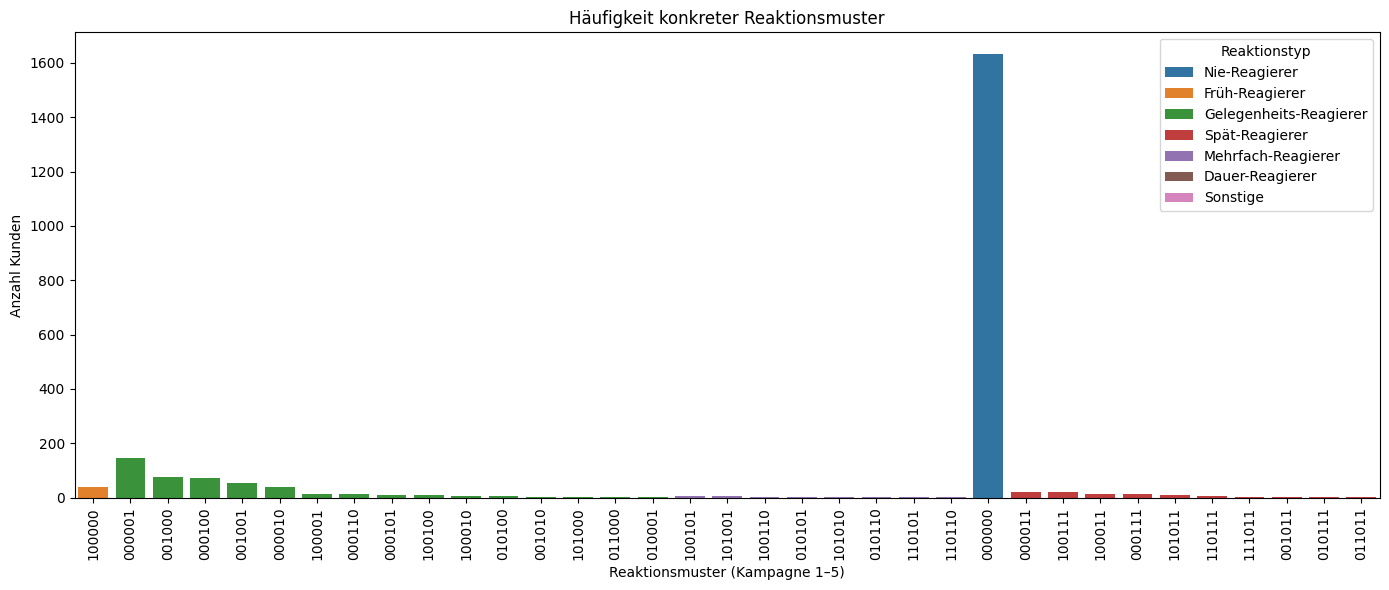

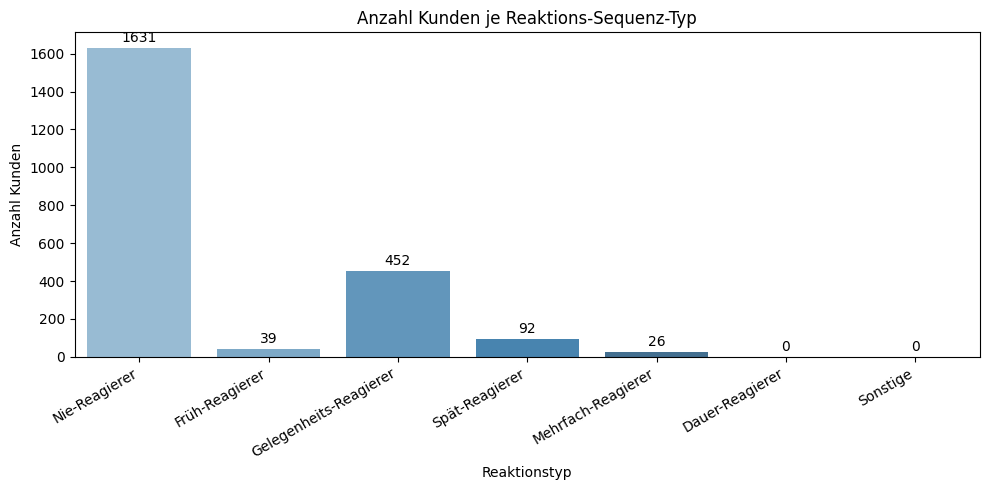


Kundenprofile je Reaktionstyp:


,Alter,Einkommen,Kundendauer_Jahre,Anzahl_Webkäufe,Anzahl_Ladeneinkäufe,Anzahl_Katalogkäufe,Anzahl_Rabattkäufe
Reaktionstyp,,,,,,,
Früh-Reagierer,52.85,73785.21,2.27,6.05,8.46,5.44,1.74
Gelegenheits-Reagierer,48.22,55666.78,2.58,4.81,6.10,3.50,2.52
Mehrfach-Reagierer,43.85,73139.04,2.45,5.81,7.85,5.85,2.12
Nie-Reagierer,46.97,48710.01,2.45,3.72,5.48,2.11,2.36
Spät-Reagierer,44.74,82895.85,2.61,5.68,7.99,6.17,0.96


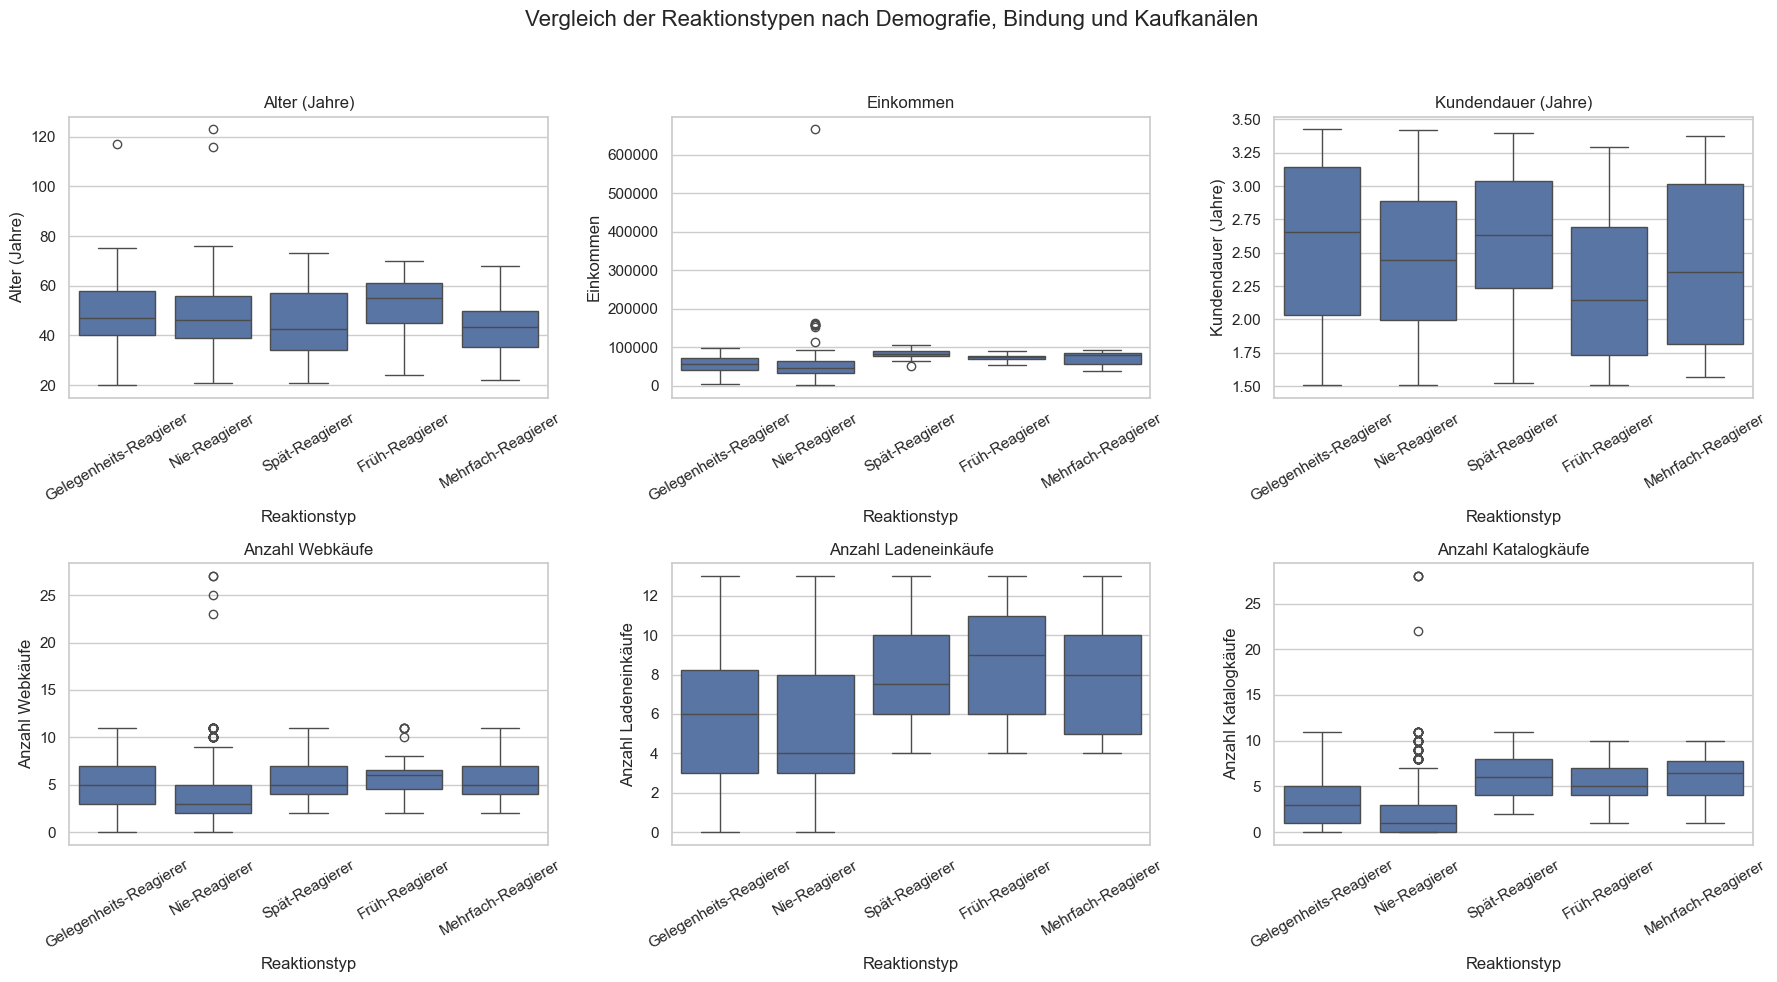


Durchschnittliche Rabattquote je Reaktionstyp:


Reaktionstyp
Früh-Reagierer            0.101
Gelegenheits-Reagierer    0.228
Mehrfach-Reagierer        0.126
Nie-Reagierer               inf
Spät-Reagierer            0.053
Name: Rabattquote, dtype: float64

In [16]:
# =========================================================
# 7.1 Kampagnen definieren & Reaktionsmuster erzeugen
# =========================================================

kampagnen_cols = [
    'Kampagne_1_Akzeptiert',
    'Kampagne_2_Akzeptiert',
    'Kampagne_3_Akzeptiert',
    'Kampagne_4_Akzeptiert',
    'Kampagne_5_Akzeptiert',
    'Antwort_Letzte_Kampagne'
]

df['Reaktionsmuster'] = df[kampagnen_cols].astype(str).agg(''.join, axis=1)
muster_counts = df['Reaktionsmuster'].value_counts()

alle_muster = [''.join(p) for p in product('01', repeat=6)]
alle_muster_df = pd.DataFrame({'Reaktionsmuster': alle_muster})

vergleich = alle_muster_df.merge(
    muster_counts.rename('Anzahl'),
    left_on='Reaktionsmuster',
    right_index=True,
    how='left'
).fillna(0)

display(vergleich.head(65))

# =========================================================
# 7.2 Reaktionstypen definieren
# =========================================================

def classify_reaktionstyp(muster: str) -> str:
    if muster == '000000':
        return 'Nie-Reagierer'
    elif muster == '111111':
        return 'Dauer-Reagierer'
    elif muster.startswith('1') and muster[1:] == '00000':
        return 'Früh-Reagierer'
    elif muster.endswith('11'):
        return 'Spät-Reagierer'
    elif muster.count('1') in [1, 2]:
        return 'Gelegenheits-Reagierer'
    elif muster.count('1') >= 3:
        return 'Mehrfach-Reagierer'
    else:
        return 'Sonstige'

df['Reaktionstyp'] = df['Reaktionsmuster'].apply(classify_reaktionstyp)

# =========================================================
# 7.3 Validierung: Zuordnung aller möglichen Muster
# =========================================================

alle_muster = [''.join(p) for p in product('01', repeat=6)]

muster_uebersicht = pd.DataFrame({'Reaktionsmuster': alle_muster})
muster_uebersicht['Reaktionstyp'] = (
    muster_uebersicht['Reaktionsmuster']
    .apply(classify_reaktionstyp)
)

print("\nÜbersicht über häufige Muster:")
display(muster_uebersicht.sort_values('Reaktionstyp'))

# =========================================================
# 7.4 Visualisierung
# =========================================================

plot_df = (
    df
    .groupby(['Reaktionsmuster', 'Reaktionstyp'])
    .size()
    .reset_index(name='Anzahl_Kunden')
)

plot_df_sorted = (
    plot_df
    .sort_values(
        ['Reaktionstyp', 'Anzahl_Kunden'],
        ascending=[True, False]
    )
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=plot_df_sorted,
    x='Reaktionsmuster',
    y='Anzahl_Kunden',
    hue='Reaktionstyp',
    dodge=False,
    hue_order=[
        'Nie-Reagierer',
        'Früh-Reagierer',
        'Gelegenheits-Reagierer',
        'Spät-Reagierer',
        'Mehrfach-Reagierer',
        'Dauer-Reagierer',
        'Sonstige'
    ]
)

plt.xlabel('Reaktionsmuster (Kampagne 1–5)')
plt.ylabel('Anzahl Kunden')
plt.title('Häufigkeit konkreter Reaktionsmuster')
plt.xticks(rotation=90)
plt.legend(title='Reaktionstyp')
plt.tight_layout()
plt.show()

reaktionstyp_order = [
    'Nie-Reagierer',
    'Früh-Reagierer',
    'Gelegenheits-Reagierer',
    'Spät-Reagierer',
    'Mehrfach-Reagierer',
    'Dauer-Reagierer',
    'Sonstige'
]

reaktion_counts = (
    df['Reaktionstyp']
    .value_counts()
    .reindex(reaktionstyp_order)
    .fillna(0)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=reaktion_counts.index,
    y=reaktion_counts.values,
    palette='Blues_d'
)

plt.xlabel('Reaktionstyp')
plt.ylabel('Anzahl Kunden')
plt.title('Anzahl Kunden je Reaktions-Sequenz-Typ')
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(reaktion_counts.values):
    plt.text(i, v + max(reaktion_counts.values)*0.01, int(v), 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# =========================================================
# 7.5 Soziodemografische & Kauf-Profile je Reaktionstyp
# =========================================================

profil_features = [
    'Alter',
    'Einkommen',
    'Kundendauer_Jahre',
    'Anzahl_Webkäufe',
    'Anzahl_Ladeneinkäufe',
    'Anzahl_Katalogkäufe',
    'Anzahl_Rabattkäufe'
]

reaktionstyp_profile = (
    df
    .groupby('Reaktionstyp')[profil_features]
    .mean()
)

print("\nKundenprofile je Reaktionstyp:")
display(reaktionstyp_profile.round(2))

sns.set(style="whitegrid")

vars_to_plot = {
    'Alter': 'Alter (Jahre)',
    'Einkommen': 'Einkommen',
    'Kundendauer_Jahre': 'Kundendauer (Jahre)',   
    'Anzahl_Webkäufe': 'Anzahl Webkäufe',
    'Anzahl_Ladeneinkäufe': 'Anzahl Ladeneinkäufe',
    'Anzahl_Katalogkäufe': 'Anzahl Katalogkäufe'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (var, label) in zip(axes, vars_to_plot.items()):
    sns.boxplot(
        data=df,
        x='Reaktionstyp',
        y=var,
        ax=ax
    )
    ax.set_title(label)
    ax.set_xlabel('Reaktionstyp')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(
    'Vergleich der Reaktionstypen nach Demografie, Bindung und Kaufkanälen',
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# =========================================================
# 7.6 Rabattquote berechnen & vergleichen
# =========================================================

df['Rabattquote'] = (
    df['Anzahl_Rabattkäufe'] /
    (
        df['Anzahl_Webkäufe'] +
        df['Anzahl_Ladeneinkäufe'] +
        df['Anzahl_Katalogkäufe']
    )
)

print("\nDurchschnittliche Rabattquote je Reaktionstyp:")
display(
    df.groupby('Reaktionstyp')['Rabattquote']
      .mean()
      .round(3)
)


4.1. Customer Journey pro Reaktionstyp

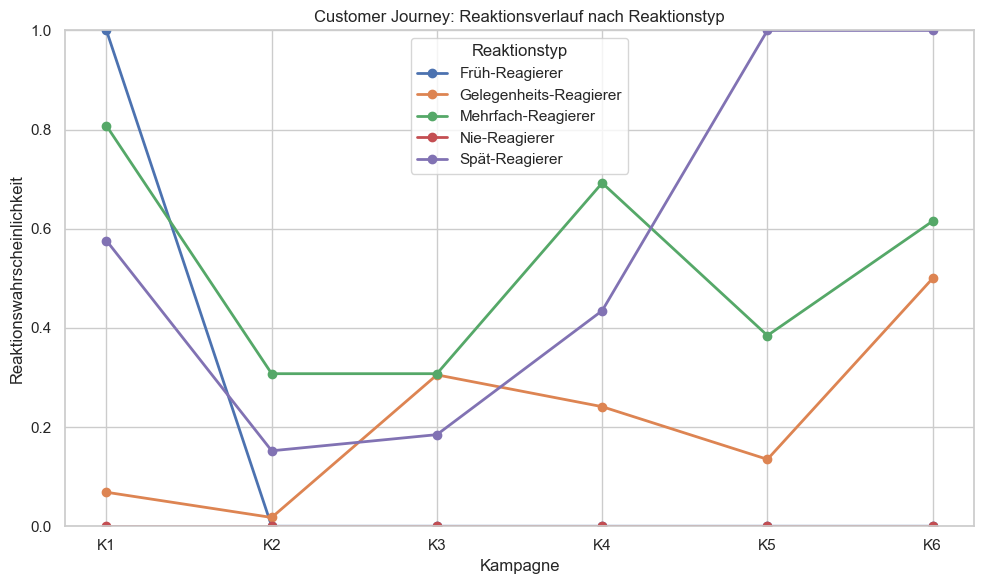

In [17]:
journey_df = (
    df
    .groupby('Reaktionstyp')[kampagnen_cols]
    .mean()
    .T
)

journey_df.index = [f"K{i+1}" for i in range(len(journey_df))]

plt.figure(figsize=(10, 6))

for typ in journey_df.columns:
    plt.plot(
        journey_df.index,
        journey_df[typ],
        marker='o',
        linewidth=2,
        label=typ
    )

plt.xlabel('Kampagne')
plt.ylabel('Reaktionswahrscheinlichkeit')
plt.title('Customer Journey: Reaktionsverlauf nach Reaktionstyp')
plt.legend(title='Reaktionstyp')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


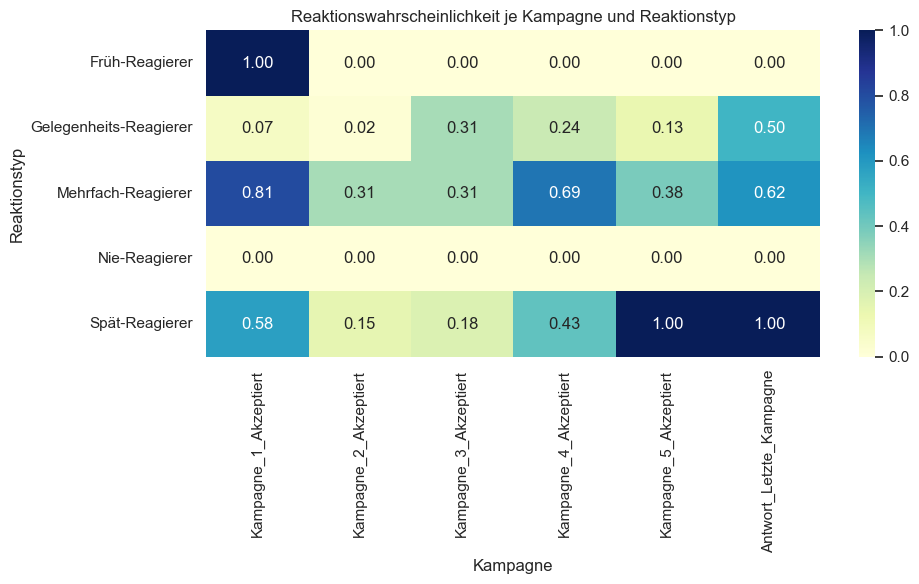

In [18]:
kampagnen_cols = [
    'Kampagne_1_Akzeptiert',
    'Kampagne_2_Akzeptiert',
    'Kampagne_3_Akzeptiert',
    'Kampagne_4_Akzeptiert',
    'Kampagne_5_Akzeptiert',
    'Antwort_Letzte_Kampagne'
]

heatmap_df = (
    df
    .groupby('Reaktionstyp')[kampagnen_cols]
    .mean()
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title('Reaktionswahrscheinlichkeit je Kampagne und Reaktionstyp')
plt.xlabel('Kampagne')
plt.ylabel('Reaktionstyp')
plt.tight_layout()
plt.show()


4.2. Markov-Ketten nach Reaktionstyp

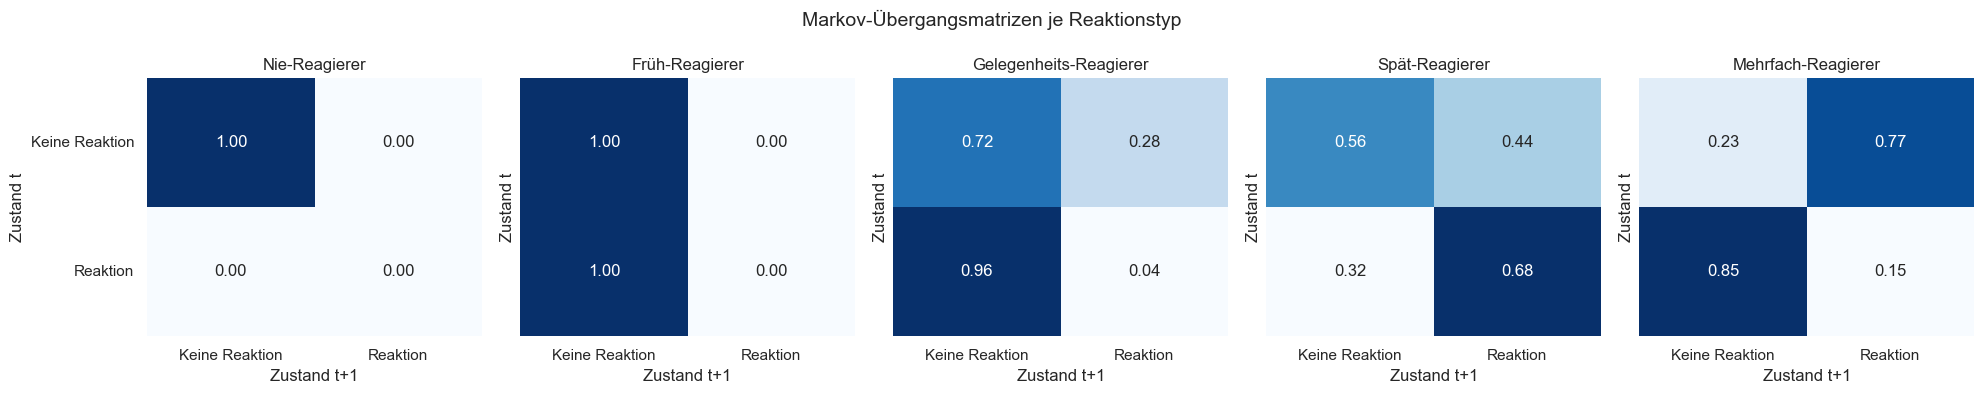

In [19]:
def compute_markov_matrix(df, kampagnen_cols, typ_col=None):

    transitions = []

    if typ_col:
        for _, row in df.iterrows():
            for t in range(len(kampagnen_cols) - 1):
                transitions.append({
                    'Typ': row[typ_col],
                    't': row[kampagnen_cols[t]],
                    't1': row[kampagnen_cols[t + 1]]
                })

        trans_df = pd.DataFrame(transitions)
        matrices = {}

        for typ in trans_df['Typ'].unique():
            tmp = trans_df[trans_df['Typ'] == typ]
            matrix = (
                pd.crosstab(tmp['t'], tmp['t1'])
                .reindex(index=[0, 1], columns=[0, 1], fill_value=0)
            )
            matrices[typ] = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)

        return matrices

    else:
        for _, row in df.iterrows():
            for t in range(len(kampagnen_cols) - 1):
                transitions.append({
                    't': row[kampagnen_cols[t]],
                    't1': row[kampagnen_cols[t + 1]]
                })

        trans_df = pd.DataFrame(transitions)
        matrix = (
            pd.crosstab(trans_df['t'], trans_df['t1'])
            .reindex(index=[0, 1], columns=[0, 1], fill_value=0)
        )
        return matrix.div(matrix.sum(axis=1), axis=0).fillna(0)

markov_matrices = compute_markov_matrix(
    df,
    kampagnen_cols,
    typ_col='Reaktionstyp'
)

order = [
    'Nie-Reagierer',
    'Früh-Reagierer',
    'Gelegenheits-Reagierer',
    'Spät-Reagierer',
    'Mehrfach-Reagierer',
    'Dauer-Reagierer'
]

markov_matrices = {
    k: markov_matrices[k]
    for k in order
    if k in markov_matrices
}
n = len(markov_matrices)
fig, axes = plt.subplots(
    1, n,
    figsize=(4 * n, 4),
    sharey=True
)

if n == 1:
    axes = [axes]

for ax, (typ, matrix) in zip(axes, markov_matrices.items()):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=False,
        ax=ax
    )
    ax.set_title(typ)
    ax.set_xlabel("Zustand t+1")
    ax.set_ylabel("Zustand t")
    ax.set_xticklabels(["Keine Reaktion", "Reaktion"])
    ax.set_yticklabels(["Keine Reaktion", "Reaktion"], rotation=0)

plt.suptitle(
    "Markov-Übergangsmatrizen je Reaktionstyp",
    fontsize=14
)
plt.tight_layout()
plt.show()


4.2. Markov-Kette nach Kampagnencluster

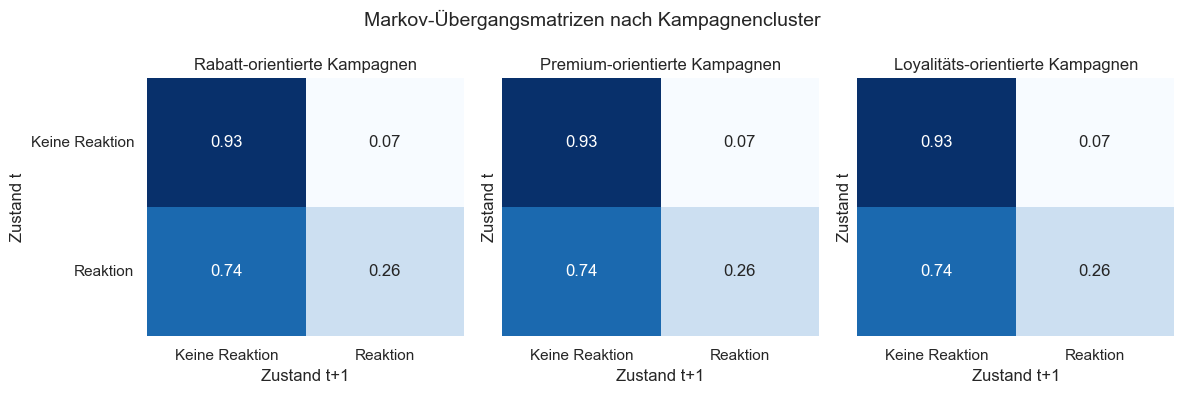

In [20]:
markov_cluster_matrices = {
    cid: compute_markov_matrix(data, kampagnen_cols)
    for cid, data in cluster_dfs.items()
}

n = len(markov_cluster_matrices)
fig, axes = plt.subplots(
    1, n,
    figsize=(4 * n, 4),
    sharey=True
)

if n == 1:
    axes = [axes]

for ax, (cid, matrix) in zip(axes, markov_cluster_matrices.items()):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=False,
        ax=ax
    )
    ax.set_title(cluster_namen[cid])
    ax.set_xlabel("Zustand t+1")
    ax.set_ylabel("Zustand t")
    ax.set_xticklabels(["Keine Reaktion", "Reaktion"])
    ax.set_yticklabels(["Keine Reaktion", "Reaktion"], rotation=0)

plt.suptitle(
    "Markov-Übergangsmatrizen nach Kampagnencluster",
    fontsize=14
)
plt.tight_layout()
plt.show()


5. Modellvergleich: LogReg vs. Random Forest (High-Response-Kunden)

Anteil High-Response-Kunden:
High_Response
0    0.983
1    0.017
Name: proportion, dtype: float64

Modell-Performance (High-Response):
AUC:      0.859
Accuracy: 0.731
Recall:   0.917

Confusion Matrix:
[[480 180]
 [  1  11]]


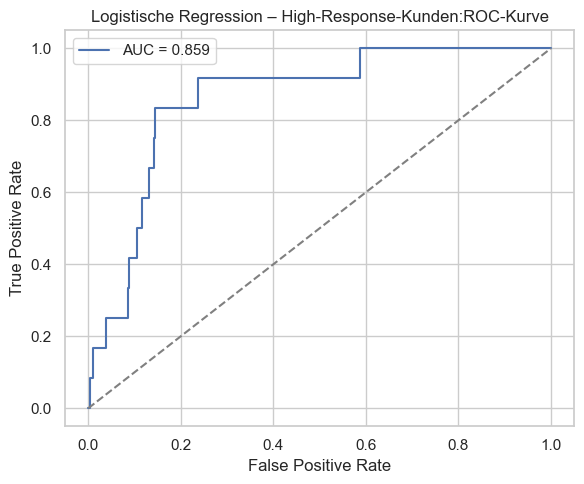

In [21]:
# =========================================================
# Logistische Regression – High-Response-Kunden:
# =========================================================

# Früh-Reagierer ODER Dauer-Reagierer

df['High_Response'] = df['Reaktionstyp'].isin(
    ['Früh-Reagierer', 'Dauer-Reagierer']
).astype(int)

print("Anteil High-Response-Kunden:")
print(df['High_Response'].value_counts(normalize=True).round(3))

# =========================================================
# Feature-Set definieren
# =========================================================

features = [
    'Alter',
    'Einkommen',
    'Kundendauer_Jahre',
    'Anzahl_Webkäufe',
    'Anzahl_Ladeneinkäufe',
    'Anzahl_Katalogkäufe',
    'Anzahl_Rabattkäufe'
]

X = df[features]
y = df['High_Response']

# =========================================================
# Train-Test-Split (stratifiziert)
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# =========================================================
# Logistische Regression (mit Klassen-Gewichtung)
# =========================================================

pipe_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

pipe_logreg.fit(X_train, y_train)

# =========================================================
# Modellbewertung
# =========================================================

y_prob = pipe_logreg.predict_proba(X_test)[:, 1]
y_pred = pipe_logreg.predict(X_test)

auc_score = roc_auc_score(y_test, y_prob)
acc_score = accuracy_score(y_test, y_pred)
recall_hr = recall_score(y_test, y_pred)

print("\nModell-Performance (High-Response):")
print(f"AUC:      {auc_score:.3f}")
print(f"Accuracy: {acc_score:.3f}")
print(f"Recall:   {recall_hr:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# =========================================================
# ROC-Kurve visualisieren
# =========================================================

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], '--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistische Regression – High-Response-Kunden:ROC-Kurve')
plt.legend()
plt.tight_layout()
plt.show()


Beste Random-Forest-Parameter:
{'max_depth': 10, 'min_samples_leaf': 5}
Random Forest – Modell-Performance:
AUC:      0.852
Accuracy: 0.972
Recall:   0.417

Confusion Matrix:
[[648  12]
 [  7   5]]


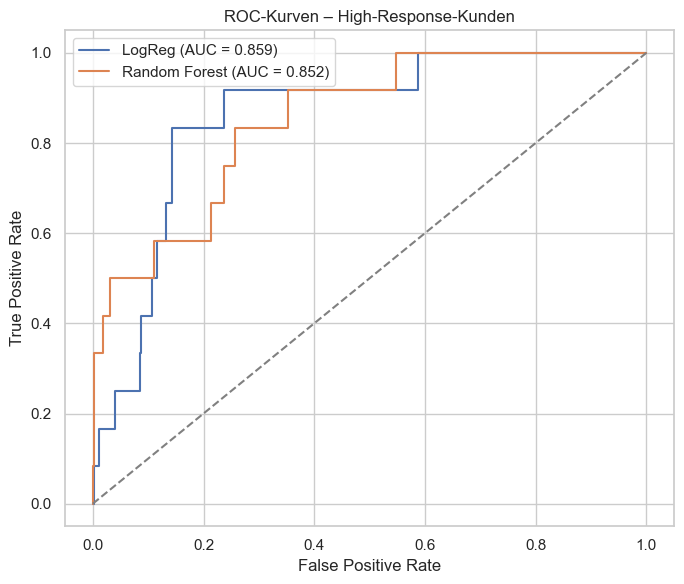

In [22]:
# =========================================================
# Random Forest – High-Response-Kunden
# =========================================================

param_grid = {
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10]
}

rf_base = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

grid_rf = GridSearchCV(
    rf_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

rf = grid_rf.best_estimator_

print("Beste Random-Forest-Parameter:")
print(grid_rf.best_params_)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

auc_rf = roc_auc_score(y_test, y_prob_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print("Random Forest – Modell-Performance:")
print(f"AUC:      {auc_rf:.3f}")
print(f"Accuracy: {acc_rf:.3f}")
print(f"Recall:   {recall_rf:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC = {auc_score:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], '--', color='grey')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Kurven – High-Response-Kunden')
plt.legend()
plt.tight_layout()
plt.show()


5.1. Threshold & Recall Bestimmung


In [23]:
thresholds = np.linspace(0, 1, 101)
target_recall = 0.70  

threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    recall = recall_score(y_test, y_pred_t)
    threshold_results.append((t, recall))

threshold_df = pd.DataFrame(
    threshold_results, columns=['Threshold', 'Recall']
)

optimal_threshold = (
    threshold_df[threshold_df['Recall'] >= target_recall]
    .iloc[-1]['Threshold']
)

print(f"🎯 Optimaler Threshold für Recall ≥ {target_recall:.0%}: {optimal_threshold:.2f}")


🎯 Optimaler Threshold für Recall ≥ 70%: 0.69


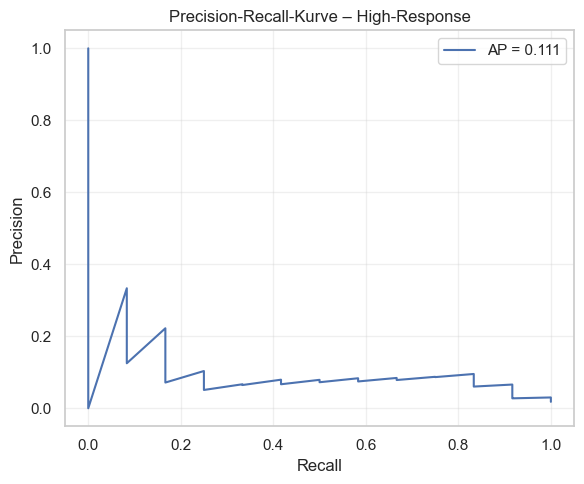

In [24]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'AP = {avg_precision:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall-Kurve – High-Response')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


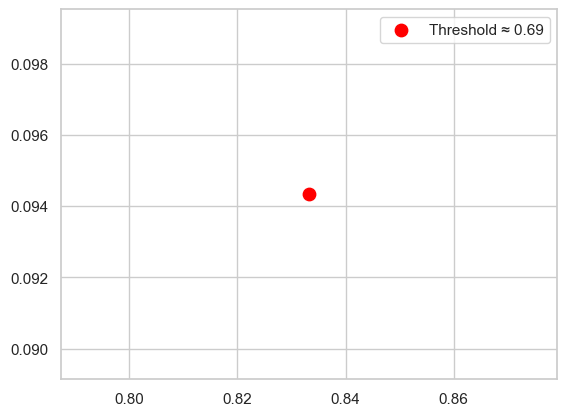

In [25]:
idx = np.argmin(np.abs(thresholds_pr - optimal_threshold))

plt.scatter(
    recall[idx+1],
    precision[idx+1],
    color='red',
    s=80,
    label=f'Threshold ≈ {optimal_threshold:.2f}'
)
plt.legend()


In [26]:
# =========================================================
# Simulationsrechner – High-Response-Kunden
# =========================================================

simulation_df = X_test.copy()
simulation_df['y_true'] = y_test.values
simulation_df['y_prob'] = y_prob

top_pct = 0.1
cutoff = simulation_df['y_prob'].quantile(1 - top_pct)

simulation_df['Targeted'] = simulation_df['y_prob'] >= cutoff

targeted_customers = simulation_df['Targeted'].sum()
true_positives = simulation_df[
    (simulation_df['Targeted']) & (simulation_df['y_true'] == 1)
].shape[0]

total_high_response = simulation_df['y_true'].sum()

print(f"Marketing-Simulation (Top {int(top_pct*100)} % Kunden)")
print(f"Angesprochene Kunden: {targeted_customers}")
print(f"Gefundene High-Response-Kunden: {true_positives}")
print(f"Abgedeckter Anteil High-Response: {true_positives / total_high_response:.1%}")


Marketing-Simulation (Top 10 % Kunden)
Angesprochene Kunden: 68
Gefundene High-Response-Kunden: 5
Abgedeckter Anteil High-Response: 41.7%


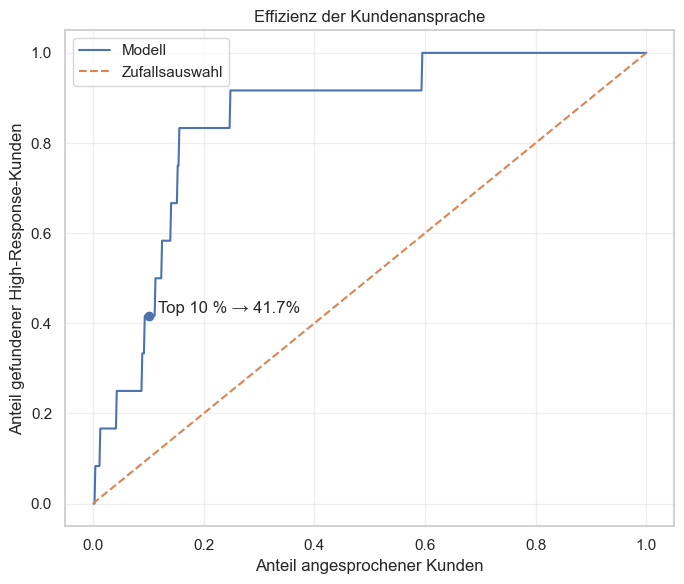

In [27]:
sim_df = pd.DataFrame({
    'y_true': y_test.values,
    'y_prob': y_prob
}).sort_values('y_prob', ascending=False)

sim_df['cum_customers'] = np.arange(1, len(sim_df) + 1)
sim_df['cum_customers_pct'] = sim_df['cum_customers'] / len(sim_df)
sim_df['cum_high_response'] = sim_df['y_true'].cumsum()
sim_df['cum_high_response_pct'] = (
    sim_df['cum_high_response'] / sim_df['y_true'].sum()
)

plt.figure(figsize=(7, 6))
plt.plot(
    sim_df['cum_customers_pct'],
    sim_df['cum_high_response_pct'],
    label='Modell'
)

plt.plot(
    [0, 1], [0, 1],
    linestyle='--',
    label='Zufallsauswahl'
)

top_pct = 0.10
idx_10 = sim_df['cum_customers_pct'].searchsorted(top_pct)

plt.scatter(
    sim_df.iloc[idx_10]['cum_customers_pct'],
    sim_df.iloc[idx_10]['cum_high_response_pct']
)

plt.text(
    sim_df.iloc[idx_10]['cum_customers_pct'],
    sim_df.iloc[idx_10]['cum_high_response_pct'],
    f"  Top 10 % → {sim_df.iloc[idx_10]['cum_high_response_pct']:.1%}",
    va='bottom'
)

plt.xlabel('Anteil angesprochener Kunden')
plt.ylabel('Anteil gefundener High-Response-Kunden')
plt.title('Effizienz der Kundenansprache')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Feature Importance (Random Forest – High-Response-Kunden - Kampagnencluster) 

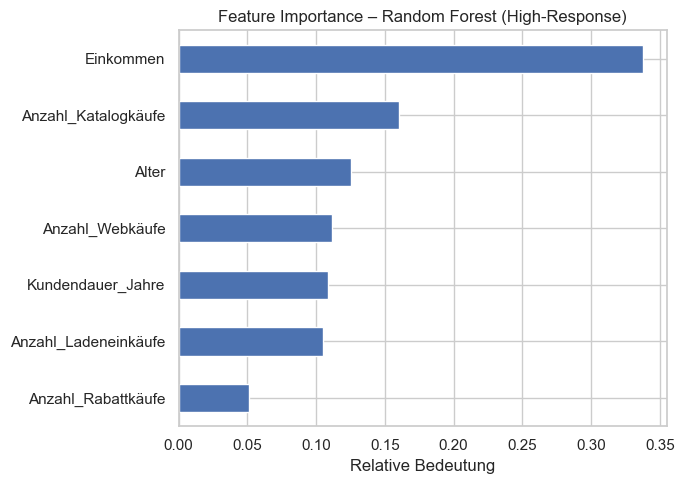

🔑 Feature Importance – High-Response-Kunden:


Einkommen               0.338
Anzahl_Katalogkäufe     0.160
Alter                   0.126
Anzahl_Webkäufe         0.112
Kundendauer_Jahre       0.109
Anzahl_Ladeneinkäufe    0.105
Anzahl_Rabattkäufe      0.051
dtype: float64

In [28]:
importances = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Relative Bedeutung')
plt.title('Feature Importance – Random Forest (High-Response)')
plt.tight_layout()
plt.show()

print("🔑 Feature Importance – High-Response-Kunden:")
display(importances.round(3))


Feature Importance je Kampagnencluster:


,Rabatt-orientierte Kampagnen,Premium-orientierte Kampagnen,Loyalitäts-orientierte Kampagnen
Alter,0.150,0.074,0.128
Anzahl_Katalogkäufe,0.129,0.183,0.123
Anzahl_Ladeneinkäufe,0.122,0.099,0.163
Anzahl_Rabattkäufe,0.068,0.100,0.062
Anzahl_Webkäufe,0.102,0.085,0.102
Einkommen,0.227,0.372,0.259
Kundendauer_Jahre,0.200,0.087,0.163


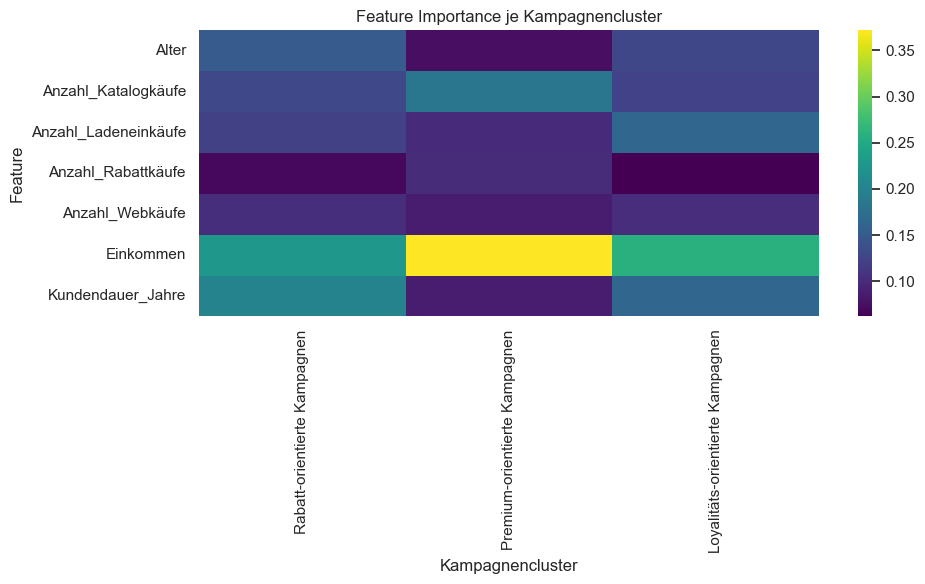

🔑 Wichtigste Treiber je Kampagnencluster:


,Top 1,Top 2,Top 3
Rabatt-orientierte Kampagnen,Einkommen,Kundendauer_Jahre,Alter
Premium-orientierte Kampagnen,Einkommen,Anzahl_Katalogkäufe,Anzahl_Rabattkäufe
Loyalitäts-orientierte Kampagnen,Einkommen,Anzahl_Ladeneinkäufe,Kundendauer_Jahre


In [29]:
# =========================================================
# Feature Importance je Kampagnencluster
# =========================================================

cluster_importances = {}

for cid, data in cluster_dfs.items():
    
    X = data[features]
    y = data['Target']
    
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    )
    rf.fit(X, y)
    
    cluster_importances[cid] = pd.Series(
        rf.feature_importances_,
        index=features
    ).sort_values(ascending=False)

importance_df = pd.DataFrame(cluster_importances)

importance_df.columns = [
    cluster_namen[cid] for cid in importance_df.columns
]

print("Feature Importance je Kampagnencluster:")
display(importance_df.round(3))

plt.figure(figsize=(10, 6))
sns.heatmap(
    importance_df,
    cmap='viridis',
    annot=False
)
plt.title('Feature Importance je Kampagnencluster')
plt.xlabel('Kampagnencluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

top_features = {
    cluster_namen[cid]: imp.head(3).index.tolist()
    for cid, imp in cluster_importances.items()
}

top_features_df = pd.DataFrame.from_dict(
    top_features,
    orient='index',
    columns=['Top 1', 'Top 2', 'Top 3']
)

print("🔑 Wichtigste Treiber je Kampagnencluster:")
display(top_features_df)


end